In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [2]:
# set a random seed for reproducibility
np.random.seed(0)

# Create a time series of 200 points
n = 200
t = np.arange(n)


In [3]:
# Create a simple trends of 0.1 * t + random noise
data = 0.1 * t + np.random.randn(n)

# Convert into pandas series for convereince
s = pd.Series(data)

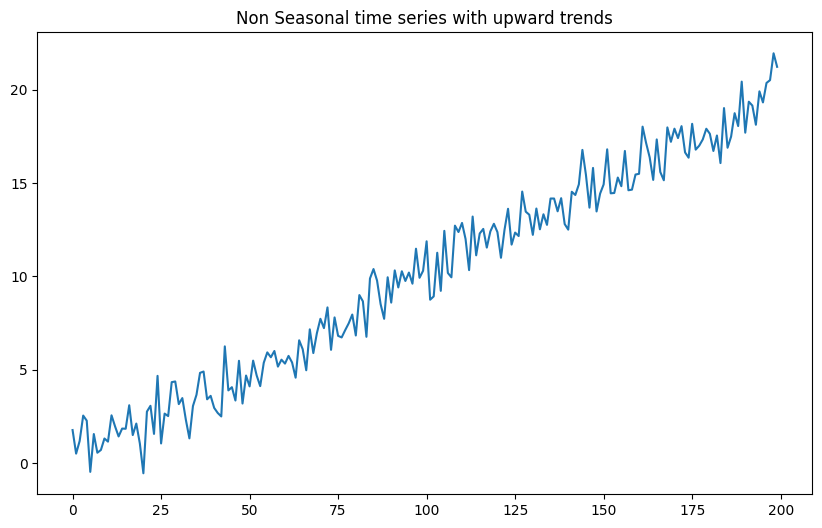

In [4]:
plt.figure(figsize=(10,6))
plt.plot(s)
plt.title("Non Seasonal time series with upward trends")
plt.show()

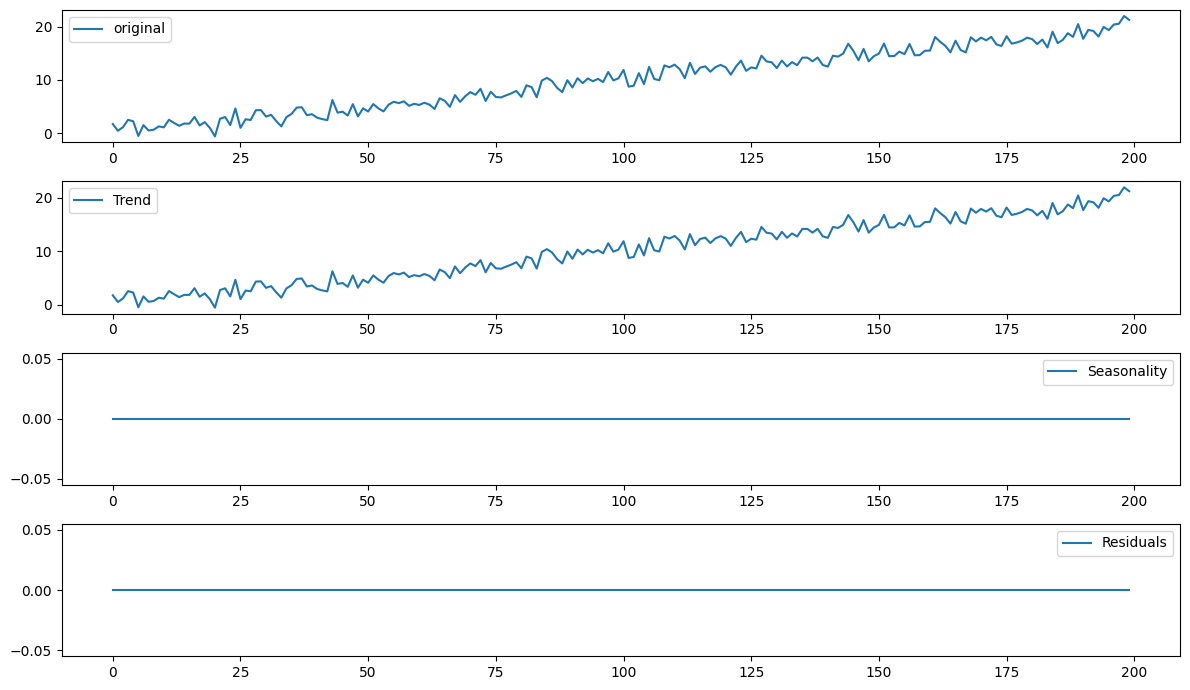

In [5]:
# Decompose the data into trends seasonal and residual components
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(s, model='additive', period=1)
trend  = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(12,7))
plt.subplot(411)
plt.plot(s, label='original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [6]:
# Fit the ARIMA model to our time series
model = ARIMA(s, order=(1,1,0))
model_fit = model.fit()

In [7]:
# Generate a forecast
forecast = model_fit.forecast(steps=5)
print(forecast)

200    21.622241
201    21.417517
202    21.526178
203    21.468504
204    21.499115
Name: predicted_mean, dtype: float64


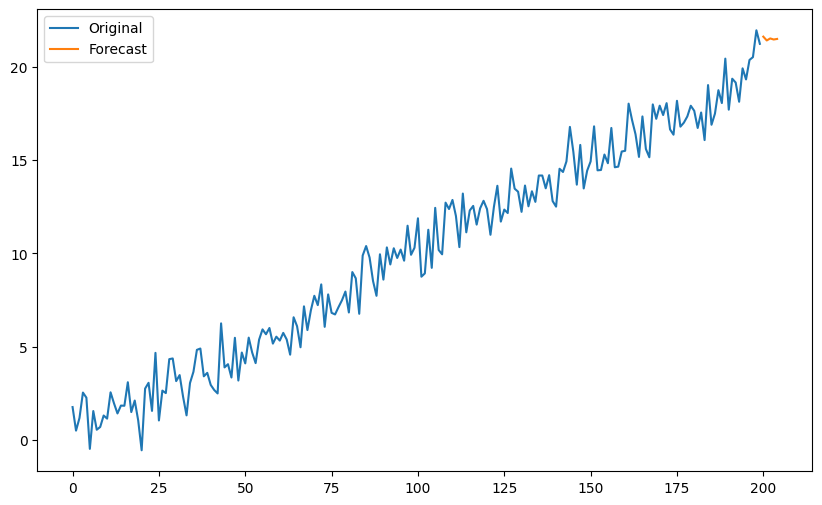

In [8]:
plt.figure(figsize=(10,6))
plt.plot(s, label='Original')
plt.plot(forecast, label='Forecast')
plt.legend(loc='best')
plt.show()

# ARIMA model in python

In [9]:
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA

data = yf.download("AAPL", start="2015-01-01", end="2025-01-01")

close_prices = data["Close"]

model = ARIMA(close_prices, order=(5, 1, 2))
model_fit = model.fit()

prediction = model_fit.predict()

print(prediction)

[*********************100%***********************]  1 of 1 completed
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Date
2015-01-02      0.000000
2015-01-05     24.192601
2015-01-06     23.518512
2015-01-07     23.530399
2015-01-08     23.855861
                 ...    
2024-12-24    253.478788
2024-12-26    256.395644
2024-12-27    257.337746
2024-12-30    253.988006
2024-12-31    250.796930
Name: predicted_mean, Length: 2516, dtype: float64


In [ ]:
import statsmodels.api as sm
import warnings
model = sm.tsa.statespace.SARIMAX(data['Close'],
                                  order=[5,1,2],
                                  seasonal_order=[5,1,2,12])
model = model.fit()
print(model.summery())

D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
prediction = model.pridict(len(data['Close']), len(df['Close'])+30)
print(pridiction)

In [ ]:
data['Close'].plot(figsize=(12,8))
prediction.plot()